## **Import Libraries and modules**

In [ ]:
import numpy as np

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D

from keras.utils import np_utils

from tensorflow.keras.datasets import mnist

Using TensorFlow backend.


## Load MNIST data into train and test sets

In [ ]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11493376/11490434 [==============================] - 0s 0us/step


(60000, 28, 28)


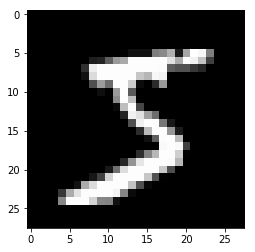

In [ ]:
print (X_train.shape)
from matplotlib import pyplot as plt
%matplotlib inline
plt.imshow(X_train[0],cmap='gray')

## Pre-processing

### Reshaping data

In [ ]:
X_train = X_train.reshape(X_train.shape[0], 28, 28,1)
X_test = X_test.reshape(X_test.shape[0], 28, 28,1)

### Pixel Normalization

In [ ]:
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
X_train /= 255
X_test /= 255

In [ ]:
y_train[:10]

array([5, 0, 4, 1, 9, 2, 1, 3, 1, 4], dtype=uint8)

### One-hot encoding

In [ ]:
# Convert 1-dimensional class arrays to 10-dimensional class matrices
Y_train = np_utils.to_categorical(y_train, 10)
Y_test = np_utils.to_categorical(y_test, 10)

In [ ]:
Y_train[:10]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]], dtype=float32)

## Model Building -- Using Convolution Layers only

In [ ]:
model = Sequential()

model.add(Conv2D(8, (3,3), activation='relu', input_shape=(28,28,1)))

model.add(Conv2D(8, (3,3), activation='relu'))
model.add(Conv2D(8, (3,3), activation='relu'))

model.add(Conv2D(8, (3,3), activation='relu'))
model.add(Conv2D(8, (3,3), activation='relu'))

model.add(Conv2D(8, (3,3), activation='relu'))
model.add(Conv2D(8, (3,3), activation='relu'))

model.add(Conv2D(8, (3,3), activation='relu'))
model.add(Conv2D(8, (3,3), activation='relu'))

model.add(Conv2D(8, (3,3), activation='relu'))
model.add(Conv2D(10, (8, 8)))

model.add(Flatten())
model.add(Activation('softmax'))

model.summary()




Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 26, 26, 8)         80        
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 24, 24, 8)         584       
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 22, 22, 8)         584       
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 20, 20, 8)         584       
_________________________________________________________________
conv2d_5 (Conv2D)            (None, 18, 18, 8)         584       
_________________________________________________________________
conv2d_6 (Conv2D)            (None, 16, 16, 8)         584       
_________________________________________________________________
conv2d_7 (Conv2D)            (None, 14, 14, 8)     

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:3: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(8, (3, 3), activation="relu", input_shape=(28, 28, 1...)`
  This is separate from the ipykernel package so we can avoid doing imports until
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:5: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(8, (3, 3), activation="relu")`
  """
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:6: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(8, (3, 3), activation="relu")`
  
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:8: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(8, (3, 3), activation="relu")`
  
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:9: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(8, (3, 3), activation="relu")`
  if __name__ == '__main__':
/usr/local/lib/python3.6/dist-packages/i

In [ ]:
model.compile(loss='categorical_crossentropy', optimizer= 'adam', metrics=['accuracy'])

model.fit(X_train, Y_train, batch_size=32, epochs=3, verbose=1, validation_data=(X_test, Y_test))



Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where



Train on 60000 samples, validate on 10000 samples
Epoch 1/3





60000/60000 [==============================] - 30s 505us/step - loss: 0.3022 - acc: 0.9053 - val_loss: 0.1428 - val_acc: 0.9568
Epoch 2/3
60000/60000 [==============================] - 27s 449us/step - loss: 0.1299 - acc: 0.9617 - val_loss: 0.1087 - val_acc: 0.9677
Epoch 3/3
60000/60000 [==============================] - 29s 476us/step - loss: 0.1021 - acc: 0.9695 - val_loss: 0.0744 - val_acc: 0.9775


## Convolution with Max Pooling

In [ ]:
model = Sequential()

model.add(Conv2D(8, (3,3), activation='relu', input_shape=(28,28,1)))

model.add(Conv2D(8, (3,3), activation='relu'))
model.add(Conv2D(8, (3,3), activation='relu'))

# Max Pooling layer
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(8, (3,3), activation='relu'))
model.add(Conv2D(8, (3,3), activation='relu'))

model.add(Conv2D(8, (3,3), activation='relu'))
model.add(Conv2D(8, (3,3), activation='relu'))

model.add(Conv2D(10, (3,3)))

model.add(Flatten())
model.add(Activation('softmax'))

model.summary()


Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_12 (Conv2D)           (None, 26, 26, 8)         80        
_________________________________________________________________
conv2d_13 (Conv2D)           (None, 24, 24, 8)         584       
_________________________________________________________________
conv2d_14 (Conv2D)           (None, 22, 22, 8)         584       
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 11, 11, 8)         0         
_________________________________________________________________
conv2d_15 (Conv2D)           (None, 9, 9, 8)           584       
_________________________________________________________________
conv2d_16 (Conv2D)           (None, 7, 7, 8)           584       
_________________________________________________________________
conv2d_17 (Conv2D)           (None, 5, 5, 8)         

In [ ]:
model.compile(loss='categorical_crossentropy',optimizer= 'adam', metrics=['accuracy'])
model.fit(X_train, Y_train, batch_size=32, epochs=3, verbose=1, validation_data=(X_test, Y_test))

Train on 60000 samples, validate on 10000 samples
Epoch 1/3
60000/60000 [==============================] - 21s 358us/step - loss: 0.4910 - acc: 0.8418 - val_loss: 0.1788 - val_acc: 0.9436
Epoch 2/3
60000/60000 [==============================] - 20s 340us/step - loss: 0.1603 - acc: 0.9518 - val_loss: 0.0998 - val_acc: 0.9684
Epoch 3/3
60000/60000 [==============================] - 20s 340us/step - loss: 0.1166 - acc: 0.9650 - val_loss: 0.0840 - val_acc: 0.9742


## Model with 1*1 Convolution 

In [ ]:
model = Sequential()

model.add(Conv2D(8, (3, 3), activation='relu', input_shape=(28,28,1)))

model.add(Conv2D(16, (3, 3), activation='relu'))
model.add(Conv2D(16, (3, 3), activation='relu'))

model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(8, (1, 1), activation='relu'))

model.add(Conv2D(16, (3, 3), activation='relu'))
model.add(Conv2D(16, (3, 3), activation='relu'))

model.add(Conv2D(10, (1, 1), activation='relu'))
model.add(Conv2D(10, (7, 7))

model.add(Flatten())
model.add(Activation('softmax'))

model.summary()





Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 26, 26, 8)         80        
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 24, 24, 16)        1168      
_________________________________________________________________
conv2d_3 (Conv2D)            (None, 22, 22, 16)        2320      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 11, 11, 16)        0         
_________________________________________________________________
conv2d_4 (Conv2D)            (None, 11, 11, 8)         136       
_________________________________________________________________
conv2d_5 (Conv2D)            (None, 9, 9, 16)          1168      
_________________________________________________________________
conv2d_6 (Conv2D)            (None, 7, 7, 16)     

/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:3: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(8, (3, 3), activation="relu", input_shape=(28, 28, 1...)`
  This is separate from the ipykernel package so we can avoid doing imports until
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:5: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(16, (3, 3), activation="relu")`
  """
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:6: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(16, (3, 3), activation="relu")`
  
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:9: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(8, (1, 1), activation="relu")`
  if __name__ == '__main__':
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:11: UserWarning: Update your `Conv2D` call to the Keras 2 API: `Conv2D(16, (3, 3), activation="relu")`
  # This is added back by InteractiveSh

In [ ]:
model.compile(loss='categorical_crossentropy',optimizer= 'adam', metrics=['accuracy'])
model.fit(X_train, Y_train, batch_size=32, epochs=3, verbose=1, validation_data=(X_test, Y_test))



Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where



Train on 60000 samples, validate on 10000 samples
Epoch 1/3





60000/60000 [==============================] - 33s 548us/step - loss: 0.2158 - acc: 0.9316 - val_loss: 0.0876 - val_acc: 0.9716
Epoch 2/3
60000/60000 [==============================] - 23s 388us/step - loss: 0.0732 - acc: 0.9777 - val_loss: 0.0551 - val_acc: 0.9823
Epoch 3/3
60000/60000 [==============================] - 23s 390us/step - loss: 0.0554 - acc: 0.9838 - val_loss: 0.0436 - val_acc: 0.9852


In [ ]:
model = Sequential()

model.add(Conv2D(4, (3, 3), activation='relu', input_shape=(28,28,1)))

model.add(Conv2D(8, (3, 3), activation='relu'))
model.add(Conv2D(16, (3, 3), activation='relu'))

model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(4, (1, 1), activation='relu'))

model.add(Conv2D(8, (3, 3), activation='relu'))
model.add(Conv2D(16, (3, 3), activation='relu'))

model.add(Conv2D(10, (1, 1), activation='relu'))
model.add(Conv2D(10, (7, 7)))

model.add(Flatten())
model.add(Activation('softmax'))

model.summary()

Model: "sequential_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_9 (Conv2D)            (None, 26, 26, 4)         40        
_________________________________________________________________
conv2d_10 (Conv2D)           (None, 24, 24, 8)         296       
_________________________________________________________________
conv2d_11 (Conv2D)           (None, 22, 22, 16)        1168      
_________________________________________________________________
max_pooling2d_2 (MaxPooling2 (None, 11, 11, 16)        0         
_________________________________________________________________
conv2d_12 (Conv2D)           (None, 11, 11, 4)         68        
_________________________________________________________________
conv2d_13 (Conv2D)           (None, 9, 9, 8)           296       
_________________________________________________________________
conv2d_14 (Conv2D)           (None, 7, 7, 16)         

In [ ]:
model.compile(loss='categorical_crossentropy',optimizer= 'adam', metrics=['accuracy'])
model.fit(X_train, Y_train, batch_size=32, epochs=3, verbose=1, validation_data=(X_test, Y_test))

Train on 60000 samples, validate on 10000 samples
Epoch 1/3
60000/60000 [==============================] - 24s 402us/step - loss: 0.2659 - acc: 0.9174 - val_loss: 0.0852 - val_acc: 0.9730
Epoch 2/3
60000/60000 [==============================] - 23s 383us/step - loss: 0.0887 - acc: 0.9730 - val_loss: 0.0717 - val_acc: 0.9769
Epoch 3/3
60000/60000 [==============================] - 23s 387us/step - loss: 0.0648 - acc: 0.9802 - val_loss: 0.0518 - val_acc: 0.9827


### Model Evaluation

In [ ]:
score = model.evaluate(X_test, Y_test, verbose=0)
print(score)

[0.08145177457807586, 0.9753]


### Model Prediction

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(y_pred[:9])
print(y_test[:9])

[[3.23383659e-07 7.14301365e-08 2.22758481e-05 2.99928884e-04
  1.63534128e-12 8.45612291e-09 3.39801246e-18 9.99670148e-01
  1.10206520e-06 6.21200979e-06]
 [1.15960279e-06 5.77195169e-06 9.99992132e-01 3.74984097e-07
  6.14736317e-10 1.09894507e-11 2.73345546e-09 3.27461392e-13
  6.05238938e-07 1.19068628e-15]
 [2.93268636e-06 9.99083877e-01 1.62235665e-04 4.01818870e-05
  4.85967212e-05 1.30269482e-05 5.04804302e-05 3.25564441e-04
  2.67411524e-04 5.51321182e-06]
 [9.99978900e-01 5.65062552e-10 7.26580595e-07 3.21644350e-10
  5.80561128e-08 7.16092359e-08 6.15807312e-06 1.36471430e-08
  5.51320092e-08 1.40077791e-05]
 [1.24681945e-10 1.65146585e-09 9.32828148e-10 1.02773234e-10
  9.99505043e-01 7.37640782e-10 2.13695173e-09 6.02243347e-07
  8.33877589e-09 4.94304346e-04]
 [4.42877621e-07 9.99695063e-01 2.10189301e-05 1.74804973e-05
  2.33889259e-05 6.86197495e-07 1.71520514e-06 1.16176627e-04
  1.22098558e-04 2.00545355e-06]
 [2.25580904e-12 2.63387733e-06 1.31810668e-06 6.32025055e

### Observation -- Train_acc: 98.5%  val_acc: 98.4%

The training accuracy is increasing over epochs.

When compare to the model with no convolution layer, it is far better as the validation accuracy is higher and the number of parameters are way too less comparatively.

Validation accuracy is lower than training accuracy. There is a hint of over-fitting here.

Let us try different techniques to address it. 

